In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# 1. Load and Preprocess Data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Reshape for CNN: (batch_size, height, width, channels)
# MNIST is grayscale, so channels = 1
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

In [5]:
# 2. Build CNN Architecture
model = models.Sequential([
    # Convolutional layer to extract features (edges, curves)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), # Downsample to reduce computation
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(), # Flatten 2D maps to 1D vector
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Output layer: 10 digits
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# 3. Compile and Train
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Training model...")
# Training for 3 epochs is usually enough to pass 95% on MNIST
history = model.fit(X_train, y_train, epochs=3, validation_split=0.1, verbose=1)

Training model...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.8802 - loss: 1.5285 - val_accuracy: 0.9800 - val_loss: 0.0699
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9782 - loss: 0.0743 - val_accuracy: 0.9778 - val_loss: 0.0773
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 29ms/step - accuracy: 0.9848 - loss: 0.0499 - val_accuracy: 0.9852 - val_loss: 0.0536


In [7]:
# 4. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")


Test Accuracy: 98.52%


In [8]:
# 5. Visualize Predictions
def plot_predictions(images, labels, model):
    predictions = model.predict(images[:5])
    plt.figure(figsize=(10, 2))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        pred_label = np.argmax(predictions[i])
        true_label = labels[i]
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis('off')
    plt.show()


Visualizing Sample Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


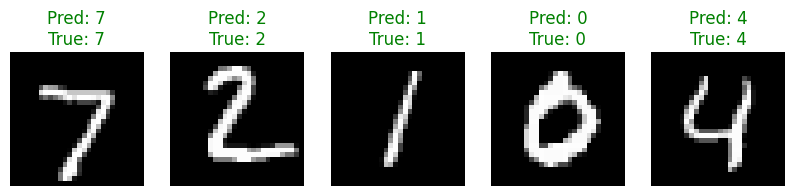

In [9]:
print("\nVisualizing Sample Predictions:")
plot_predictions(X_test, y_test, model)